# Assignment 5: Epipolar geometry and triangulation

## Exercise 1: Disparity

1a)

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import a5_utils as a5
%matplotlib inline

The equation for disparity is d = f*T / $p_z$
Disparity is inversely proportional to the distance of the point from the camera.
When the point is close to the camera, $p_z$ is small and the disparity is large. As the point moves farther away from the camera, $p_z$ increases and the disparity decreases.

1b)

In [23]:
def disparity():
    f = 2.5 #mm
    T = 120 #mm
    pz = np.linspace(100, 1000, 5000)
    disp = f * T /pz

    plt.plot(pz, disp)
    plt.xlabel('Depth (pz) [mm]')
    plt.ylabel('Disparity [mm]')
    plt.show()
    return

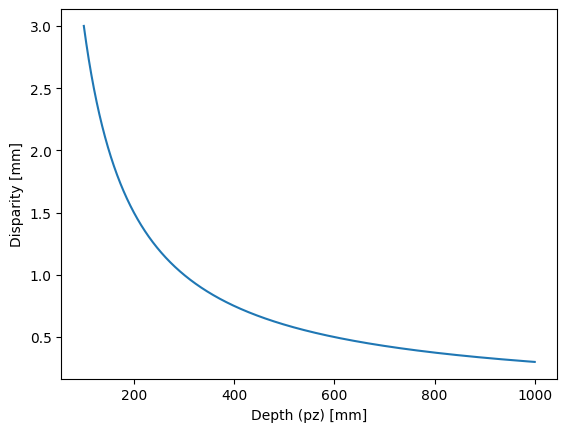

In [24]:
disparity()

1c) - solved in my notes

1d)*

In [25]:
def compute_ncc(X, Y):
    X = X.flatten()
    Y = Y.flatten()

    X_mean = np.mean(X)
    Y_mean = np.mean(Y)

    num = np.sum((X - X_mean)*(Y - Y_mean))
    den = np.sqrt(np.sum((X - X_mean)**2) * np.sum((Y - Y_mean)**2))

    if den == 0:
        return 0
    return num / den

In [26]:
def task_1d(patch_radius = 10, max_disp = 50):
    img1 = cv2.imread('./data/disparity/office_left.png', cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread('./data/disparity/office_right.png', cv2.IMREAD_GRAYSCALE)
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)

    H, W = img1.shape
    disp = np.zeros((H,W), dtype=np.float32)

    for y in range(patch_radius, H - patch_radius):
        for x in range(patch_radius, W - patch_radius):
            patchL = img1[y - patch_radius : y + patch_radius + 1,
                          x - patch_radius : x + patch_radius + 1]
            best_ncc = -1.0
            best_disp = 0

            for d in range(max_disp + 1):
                xr = x - d
                if xr - patch_radius < 0 or xr + patch_radius >= W:
                    break

                patchR = img2[y - patch_radius : y + patch_radius + 1,
                              xr - patch_radius : xr + patch_radius + 1]

                ncc = compute_ncc(patchL, patchR)

                if ncc > best_ncc:
                    best_ncc = ncc
                    best_disp = d

            disp[y, x] = best_disp

    img1_small = cv2.resize(img1, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
    disp_small = cv2.resize(disp, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_NEAREST)
    disp_norm_small = disp_small / disp_small.max()
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img1_small, cmap='gray')

    plt.subplot(1, 2, 2)
    plt.imshow(disp_norm_small, cmap='gray')
    plt.tight_layout()
    plt.show()

    return disp

In [27]:
# _ = task_1d()

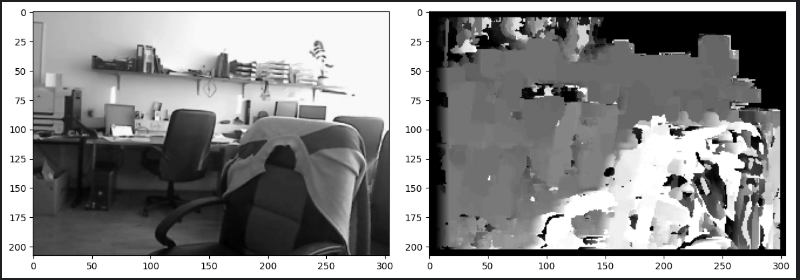

## Exercise 2: Fundamental matrix, epipoles, epipolar lines

2a) solved in my notes

2b)

In [28]:
def fundamental_matrix(points1, points2):
    norm_points1, T1 = a5.normalize_points(points1)
    norm_points2, T2 = a5.normalize_points(points2)

    N = norm_points1.shape[0]
    A = np.zeros((N, 9))

    for i in range(N):
        u, v, _ = norm_points1[i]
        u2, v2, _ = norm_points2[i]

        A[i] = [u*u2, u2*v, u2, u*v2, v*v2, v2, u, v, 1]

    _, _, VT = np.linalg.svd(A)
    F = VT[-1].reshape(3,3)

    U, D, VT = np.linalg.svd(F)
    D[-1] = 0
    F = U @ np.diag(D) @ VT

    return T2.T @ F @ T1

Fundamental matrix F:
 [[-1.09465872e-08  2.52163236e-07  4.71235273e-05]
 [ 1.11658611e-06 -9.61221997e-08 -5.74805512e-03]
 [-3.62025050e-05  5.27601159e-03 -7.32571180e-03]]
Rank of F: 2


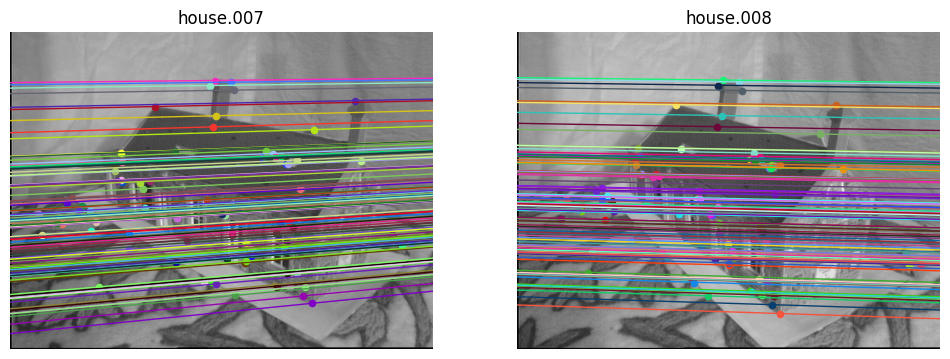

In [29]:
img1 = cv2.imread('data/house/images/house.007.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('data/house/images/house.008.png', cv2.IMREAD_GRAYSCALE)

keypoints1 = np.loadtxt('data/house/2D/house.007.corners')
keypoints2 = np.loadtxt('data/house/2D/house.008.corners')

matches = a5.read_matches('data/house/2D/house.nview-corners', 7, 8)

points1 = []
points2 = []

for i, j in matches:
    points1.append(keypoints1[i])
    points2.append(keypoints2[j])

points1 = np.array(points1)
points2 = np.array(points2)

F = fundamental_matrix(points1, points2)

print("Fundamental matrix F:\n", F)
print("Rank of F:", np.linalg.matrix_rank(F))

num_lines = 100

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img1, cmap='gray')

h, w = img1.shape
for i in range(num_lines):
    clr = np.random.rand(3,)

    plt.scatter(points1[i,0], points1[i,1], color=clr, s=20)
    x2 = np.array([points2[i,0], points2[i,1], 1])
    l = F.T @ x2
    a5.draw_epiline(l, h, w, clr)

plt.title('house.007')
plt.axis('off')


plt.subplot(1,2,2)
plt.imshow(img2, cmap='gray')
h, w = img2.shape

for i in range(num_lines):
    clr = np.random.rand(3,)

    plt.scatter(points2[i,0], points2[i,1], color=clr, s=20)
    x1 = np.array([points1[i,0], points1[i,1], 1])
    l = F @ x1
    a5.draw_epiline(l, h, w, clr)

plt.title('house.008')
plt.axis('off')

plt.show()

2c)

In [30]:
def reprojection_error(F, p1, p2):
    p1_h = np.array([p1[0], p1[1], 1])
    p2_h = np.array([p2[0], p2[1], 1])

    l2 = F @ p1_h
    a, b, c = l2
    x2, y2 = p2
    d2 = abs(a*x2 + b*y2 + c) / np.sqrt(a*a + b*b)

    l1 = F.T @ p2_h
    a, b, c = l1
    x1, y1 = p1
    d1 = abs(a*x1 + b*y1 + c) / np.sqrt(a*a + b*b)

    return (d1 + d2) / 2

In [31]:
img1 = cv2.imread('data/house/images/house.007.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('data/house/images/house.008.png', cv2.IMREAD_GRAYSCALE)

keypoints1 = np.loadtxt('data/house/2D/house.007.corners')
keypoints2 = np.loadtxt('data/house/2D/house.008.corners')

matches = a5.read_matches('data/house/2D/house.nview-corners', 7, 8)

points1 = []
points2 = []

for i, j in matches:
    points1.append(keypoints1[i])
    points2.append(keypoints2[j])

points1 = np.array(points1)
points2 = np.array(points2)

F = fundamental_matrix(points1, points2)

print("Reprojection error for points:",reprojection_error(F, [160, 463], [128, 437]))

errors = []

for i in range(len(points1)):
    e = reprojection_error(F, points1[i], points2[i])
    errors.append(e)

average_error = np.mean(errors)
print("Average reprojection error:", average_error)


Reprojection error for points: 0.5232977909191563
Average reprojection error: 0.41858395625174005


2d)*

In [32]:
def ransac(points1, points2, max_iters=2000, threshold=1.0):
    best_F = None
    best_inliers = None
    max_num_inliers = 0

    N = len(points1)

    for _ in range(max_iters):
        idx = np.random.choice(N, 8, replace=False)
        subset1 = points1[idx]
        subset2 = points2[idx]

        F = fundamental_matrix(subset1, subset2)

        errors = np.array([
            reprojection_error(F, points1[i], points2[i])
            for i in range(N)
        ])

        inliers = errors < threshold
        num_inliers = np.sum(inliers)

        if num_inliers > max_num_inliers:
            max_num_inliers = num_inliers
            best_inliers = inliers
            best_F = F

    if best_inliers is not None:
        final_F = fundamental_matrix(
            points1[best_inliers],
            points2[best_inliers]
        )

        final_errors = [
            reprojection_error(final_F, points1[i], points2[i])
            for i in range(N) if best_inliers[i]
        ]
        final_error = np.mean(final_errors)
    else:
        final_F = best_F
        final_error = None

    return final_F, best_inliers, final_error

In [33]:
def task_2d():
    desk1 = cv2.imread('data/desk/DSC02639.JPG', cv2.IMREAD_GRAYSCALE)
    desk2 = cv2.imread('data/desk/DSC02640.JPG', cv2.IMREAD_GRAYSCALE)

    sift = cv2.SIFT_create()

    kp1, des1 = sift.detectAndCompute(desk1, None)
    kp2, des2 = sift.detectAndCompute(desk2, None)

    bf = cv2.BFMatcher(cv2.NORM_L2)
    matches = bf.knnMatch(des1, des2, k=2)

    good_matches = []

    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    points1 = np.array([kp1[m.queryIdx].pt for m in good_matches])
    points2 = np.array([kp2[m.trainIdx].pt for m in good_matches])

    F, inliers, error = ransac(points1, points2)

    inliers1 = points1[inliers]
    inliers2 = points2[inliers]

    num_lines = min(70, len(inliers1))

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.imshow(desk1, cmap='gray')

    h, w = desk1.shape
    for i in range(num_lines):
        clr = np.random.rand(3,)

        plt.scatter(inliers1[i,0], inliers1[i,1], color=clr, s=20)
        x2 = np.array([inliers2[i,0], inliers2[i,1], 1])
        l = F.T @ x2
        a5.draw_epiline(l, h, w, clr)

    plt.title('DSC02639')
    plt.axis('off')


    plt.subplot(1,2,2)
    plt.imshow(desk2, cmap='gray')
    h, w = desk2.shape

    for i in range(num_lines):
        clr = np.random.rand(3,)

        plt.scatter(inliers2[i,0], inliers2[i,1], color=clr, s=20)
        x1 = np.array([inliers1[i,0], inliers1[i,1], 1])
        l = F @ x1
        a5.draw_epiline(l, h, w, clr)

    plt.title('DSC02640')
    plt.axis('off')

    plt.show()
    return

In [34]:
# task_2d()

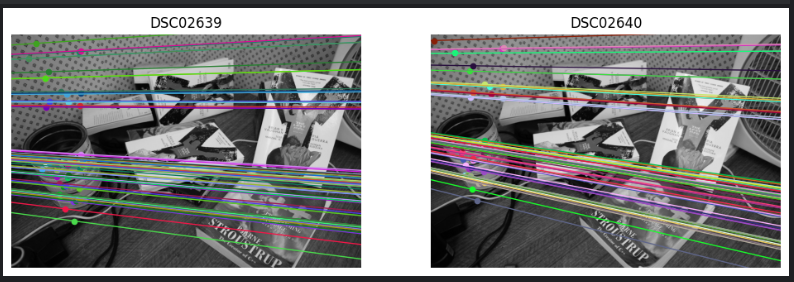

3a)

In [35]:
def triangulate(correspondences, P1, P2):
    result = []
    for x1, x2 in zip(correspondences[:,0], correspondences[:,1]):
        x1_h = np.array([x1[0],x1[1], 1])
        x2_h = np.array([x2[0],x2[1], 1])

        x1_m = np.array([[0, -x1_h[2], x1_h[1]],
                        [x1_h[2], 0 , -x1_h[0]],
                        [-x1_h[1], x1_h[0], 0]])
        x2_m = np.array([[0, -x2_h[2], x2_h[1]],
                        [x2_h[2], 0, -x2_h[0]],
                        [-x2_h[1], x2_h[0], 0]])

        M1 = x1_m @ P1
        M2 = x2_m @ P2

        A = np.array([M1[0], M1[1], M2[0], M2[1]])
        _, _, Vt = np.linalg.svd(A)

        V = Vt.T
        X = V[:,-1]
        result.append(X[:-1]/X[-1])
    return np.array(result)

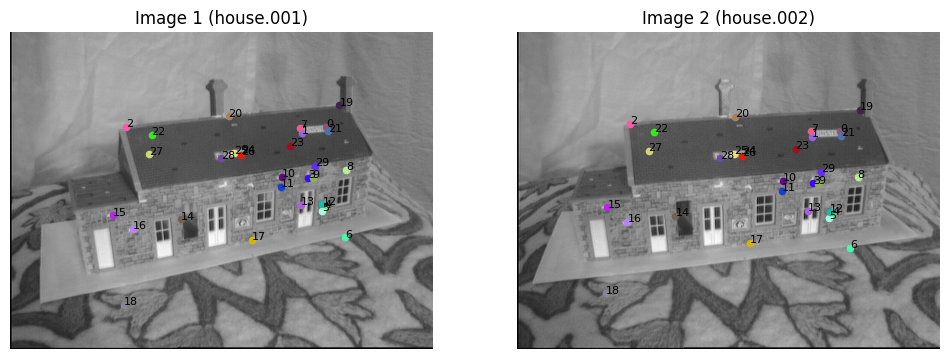

In [36]:
%matplotlib inline

img1 = cv2.imread('data/house/images/house.001.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('data/house/images/house.002.png', cv2.IMREAD_GRAYSCALE)

P1 = np.loadtxt('data/house/3D/house.001.P')
P2 = np.loadtxt('data/house/3D/house.002.P')

keypoints1 = np.loadtxt('data/house/2D/house.001.corners')
keypoints2 = np.loadtxt('data/house/2D/house.002.corners')

matches = a5.read_matches('data/house/2D/house.nview-corners', 1, 2)

correspondences = []

for i, j in matches:
    p1, p2 = keypoints1[i], keypoints2[j]
    correspondences.append([p1, p2])

correspondences = np.array(correspondences)
X = triangulate(correspondences, P1, P2)

T = np.array([
    [-1, 0, 0],
    [ 0, 0, -1],
    [ 0, 1, 0]
])

X_vis = np.array([T @ x for x in X])

pts1 = correspondences[:, 0, :]
pts2 = correspondences[:, 1, :]

N = len(correspondences)
colors = np.random.rand(N, 3)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Image 1 ----
axes[0].imshow(img1, cmap='gray')
axes[0].set_title('Image 1 (house.001)')
axes[0].axis('off')

# ---- Image 2 ----
axes[1].imshow(img2, cmap='gray')
axes[1].set_title('Image 2 (house.002)')
axes[1].axis('off')

K = min(30, len(correspondences))

for i in range(K):
    axes[0].scatter(pts1[i,0], pts1[i,1], color=colors[i], s=20)
    axes[1].scatter(pts2[i,0], pts2[i,1], color=colors[i], s=20)

    axes[0].text(
        pts1[i,0], pts1[i,1],
        str(i),
        color='black',
        fontsize=8
    )
    axes[1].text(
        pts2[i,0], pts2[i,1],
        str(i),
        color='black',
        fontsize=8
    )

plt.show()

In [37]:
import matplotlib
matplotlib.use('TkAgg')

In [38]:
def show_3d():
    import matplotlib
    matplotlib.use('TkAgg')
    plt.figure()
    ax = plt.axes(projection='3d')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.view_init(elev=30, azim=-70)

    for i in range(K):
        ax.scatter(
            X_vis[i,0], X_vis[i,1], X_vis[i,2],
            color=colors[i],
            s=30
        )
        ax.text(
            X_vis[i,0], X_vis[i,1], X_vis[i,2],
            str(i),
            color='black',
            fontsize=8
        )

    plt.show(block=True)
    return

In [39]:
# show_3d()
%matplotlib inline